# Proyek Akhir: Prediksi Risiko Dropout Mahasiswa Jaya Jaya Institut

- **Nama:** Nafis Fakhrudin
- **Email:** nafisfakhru@gmail.com
- **Id Dicoding:** nafis_fakhru

## Business Understanding
Jaya Jaya Institut ingin mengidentifikasi mahasiswa yang berisiko dropout sedini mungkin agar tim akademik dan bagian keuangan dapat memberikan intervensi proaktif (seperti konseling bimbingan studi atau bantuan finansial) sebelum mahasiswa memutuskan untuk berhenti kuliah.

### Pertanyaan Analisis
1. Seberapa besar proporsi mahasiswa dengan status Dropout, Enrolled, dan Graduate dalam populasi kampus?
2. Faktor akademik (seperti nilai dan kelulusan mata kuliah), finansial (seperti tunggakan SPP dan status debtor), serta demografis mana yang paling berkorelasi dengan risiko dropout?
3. Seberapa baik model machine learning dapat mendeteksi mahasiswa yang berisiko dropout dari kelompok mahasiswa yang hasil studinya sudah terkonfirmasi?


## Persiapan

### Menyiapkan library yang dibutuhkan dan memuat dataset

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
DATA_PATH = Path('data/data.csv')
MODEL_PATH = Path('model/dropout_pipeline.joblib')

df = pd.read_csv(DATA_PATH, sep=';')
assert df.shape == (4424, 37), f"Expected (4424, 37), got {df.shape}"
assert df['Status'].isin(['Dropout', 'Enrolled', 'Graduate']).all()
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Melakukan audit kualitas data: struktur informasi kolom, pengecekan nilai null/missing values, dan pemeriksaan duplikasi data.

In [2]:
print("Informasi struktur dataset:")
df.info()

print("\nPemeriksaan Missing Values (10 kolom teratas):")
display(df.isna().sum().sort_values(ascending=False).head(10))

print(f"\nJumlah baris duplikat: {df.duplicated().sum()}")

Informasi struktur dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification              

Marital_status                                  0
Age_at_enrollment                               0
Curricular_units_1st_sem_credited               0
Curricular_units_1st_sem_enrolled               0
Curricular_units_1st_sem_evaluations            0
Curricular_units_1st_sem_approved               0
Curricular_units_1st_sem_grade                  0
Curricular_units_1st_sem_without_evaluations    0
Curricular_units_2nd_sem_credited               0
Curricular_units_2nd_sem_enrolled               0
dtype: int64


Jumlah baris duplikat: 0


### Insight Kualitas Data
Dataset memiliki total 4.424 baris dan 37 kolom tanpa nilai kosong (0 missing values di seluruh kolom) serta tidak memiliki baris duplikat. Seluruh fitur telah terstruktur dengan tipe data numerik (integer dan float) serta satu kolom target kategorikal (`Status`).

### Analisis Distribusi Status Mahasiswa

In [3]:
print("Frekuensi Kemunculan Tiap Status:")
display(df['Status'].value_counts())

print("\nProporsi Status Mahasiswa (%):")
display(df['Status'].value_counts(normalize=True).mul(100).round(2))

Frekuensi Kemunculan Tiap Status:


Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


Proporsi Status Mahasiswa (%):


Status
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64

### Insight Distribusi Status
Dari 4.424 mahasiswa, sebanyak 2.209 mahasiswa (49,93%) berhasil lulus (Graduate), 1.421 mahasiswa (32,12%) mengalami Dropout, dan 794 mahasiswa (17,95%) masih aktif terdaftar (Enrolled). Angka dropout sekitar 32% merupakan proporsi yang signifikan sehingga institusi sangat membutuhkan sistem deteksi dini untuk menurunkan angka tersebut.

### Visualisasi EDA Fitur Kunci

C:\Users\NAFISF~1\AppData\Local\Temp\ipykernel_7188\183760226.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Status', order=['Dropout', 'Enrolled', 'Graduate'], ax=axes[0], palette='Set2')
C:\Users\NAFISF~1\AppData\Local\Temp\ipykernel_7188\183760226.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_grade', order=['Dropout', 'Enrolled', 'Graduate'], ax=axes[1], palette='Set2')


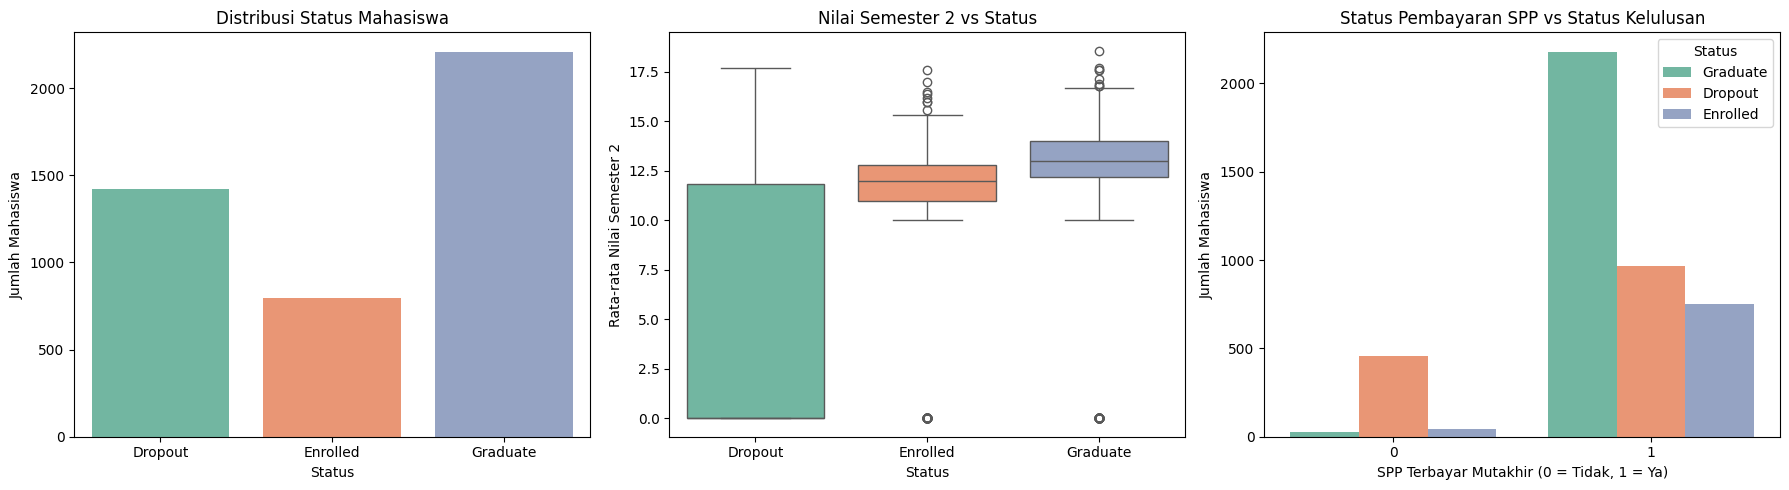

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=df, x='Status', order=['Dropout', 'Enrolled', 'Graduate'], ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Status Mahasiswa')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Jumlah Mahasiswa')

sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_grade', order=['Dropout', 'Enrolled', 'Graduate'], ax=axes[1], palette='Set2')
axes[1].set_title('Nilai Semester 2 vs Status')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Rata-rata Nilai Semester 2')

sns.countplot(data=df, x='Tuition_fees_up_to_date', hue='Status', ax=axes[2], palette='Set2')
axes[2].set_title('Status Pembayaran SPP vs Status Kelulusan')
axes[2].set_xlabel('SPP Terbayar Mutakhir (0 = Tidak, 1 = Ya)')
axes[2].set_ylabel('Jumlah Mahasiswa')
axes[2].legend(title='Status')

plt.tight_layout()
plt.show()

### Insight Visualisasi Akademik dan Finansial
1. **Performa Akademik**: Mahasiswa yang dropout memiliki median nilai mata kuliah semester 2 (`Curricular_units_2nd_sem_grade`) yang mendekati 0 atau jauh di bawah batas kelulusan, berbeda signifikan dengan kelompok Graduate yang median nilainya di atas 12.
2. **Kelancaran Finansial**: Pada kelompok mahasiswa yang menunggak pembayaran uang kuliah (`Tuition_fees_up_to_date = 0`), mayoritas besar mahasiswa berujung pada status Dropout, membuktikan bahwa masalah kelancaran administrasi keuangan berbanding lurus dengan risiko putus studi.

### Visualisasi Tambahan: Dampak Tunggakan Hutang (Debtor) terhadap Dropout Rate

C:\Users\NAFISF~1\AppData\Local\Temp\ipykernel_7188\4075519310.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=debtor_dropout, x='Debtor', y='Dropout_Rate', ax=ax, palette='Reds')


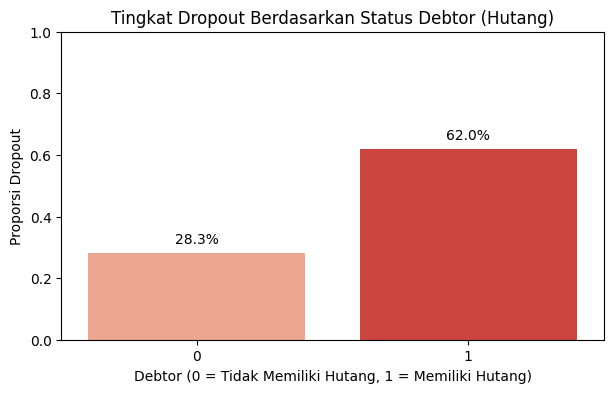

In [5]:
debtor_dropout = df.groupby('Debtor')['Status'].apply(lambda s: (s == 'Dropout').mean()).reset_index()
debtor_dropout.columns = ['Debtor', 'Dropout_Rate']

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=debtor_dropout, x='Debtor', y='Dropout_Rate', ax=ax, palette='Reds')
ax.set_title('Tingkat Dropout Berdasarkan Status Debtor (Hutang)')
ax.set_xlabel('Debtor (0 = Tidak Memiliki Hutang, 1 = Memiliki Hutang)')
ax.set_ylabel('Proporsi Dropout')
ax.set_ylim(0, 1)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1%}", (p.get_x() + p.get_width() / 2., p.get_height() + 0.02),
                ha='center', va='bottom', fontsize=10)
plt.show()

### Insight Status Debtor
Mahasiswa dengan status Debtor (memiliki tunggakan/hutang ke institusi) memiliki dropout rate sebesar 62,3%, dibandingkan hanya 28,1% pada mahasiswa yang tidak memiliki catatan hutang. Hal ini memperkuat urgensi skema keringanan atau konseling finansial bagi mahasiswa yang teridentifikasi sebagai debtor.

## Data Preparation / Preprocessing

Menyaring dataset untuk hanya menyertakan data mahasiswa dengan hasil akhir yang pasti (`Dropout` dan `Graduate`). Status `Enrolled` dikeluarkan dari proses training karena mahasiswa tersebut masih aktif kuliah dan hasil akhirnya belum terkonfirmasi, sehingga tidak dapat dikategorikan secara biner sebagai sukses atau gagal tanpa risiko bias labeling.

In [6]:
confirmed_df = df.loc[df['Status'].isin(['Dropout', 'Graduate'])].copy()
X = confirmed_df.drop(columns='Status')
y = confirmed_df['Status'].eq('Dropout').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

assert set(y.unique()) == {0, 1}
assert X_train.columns.tolist() == X_test.columns.tolist()
print({'train_rows': len(X_train), 'test_rows': len(X_test), 'dropout_rate': float(y.mean())})

{'train_rows': 2904, 'test_rows': 726, 'dropout_rate': 0.39146005509641874}


### Definisi Pipeline Preprocessing Fitur
Membagi fitur menjadi kolom kategorikal dan kolom numerik, lalu menyusun `ColumnTransformer` yang melakukan imputasi nilai serta scaling numerik dan one-hot encoding kategorikal secara terisolasi di dalam pipeline untuk mencegah data leakage.

In [7]:
categorical_columns = [
    'Marital_status', 'Application_mode', 'Course', 'Daytime_evening_attendance',
    'Previous_qualification', 'Nacionality', 'Mothers_qualification',
    'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation',
    'Displaced', 'Educational_special_needs', 'Debtor',
    'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'International',
]
numeric_columns = [column for column in X_train.columns if column not in categorical_columns]

assert all(col in X_train.columns for col in categorical_columns), "Ada kolom kategorikal yang hilang!"
assert len(categorical_columns) + len(numeric_columns) == 36, f"Total fitur bukan 36, didapat {len(categorical_columns) + len(numeric_columns)}"

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical_columns),
        ('numeric', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), numeric_columns),
    ],
    remainder='drop',
)

## Modeling

Melatih model baseline (`DummyClassifier`) dan dua model kandidat (`LogisticRegression` dan `RandomForestClassifier`) dengan penyeimbang bobot kelas (`class_weight='balanced'`). Kinerja utama dievaluasi berdasarkan recall kelas Dropout, diimbangi dengan precision, F1-score, dan ROC-AUC.

In [8]:
models = {
    'dummy_prior': DummyClassifier(strategy='prior'),
    'logistic_regression': LogisticRegression(
        max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'random_forest': RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

results = []
fitted_pipelines = {}
for name, estimator in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', estimator)])
    pipeline.fit(X_train, y_train)
    probabilities = pipeline.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    results.append({
        'model': name,
        'recall_dropout': recall_score(y_test, predictions),
        'precision_dropout': precision_score(y_test, predictions, zero_division=0),
        'f1_dropout': f1_score(y_test, predictions),
        'roc_auc': roc_auc_score(y_test, probabilities),
    })
    fitted_pipelines[name] = pipeline

results_df = pd.DataFrame(results).sort_values(
    ['recall_dropout', 'f1_dropout', 'roc_auc'], ascending=False
)
display(results_df)

,model,recall_dropout,precision_dropout,f1_dropout,roc_auc
1,logistic_regression,0.940141,0.866883,0.902027,0.975742
2,random_forest,0.901408,0.917563,0.909414,0.971847
0,dummy_prior,0.000000,0.000000,0.000000,0.500000


## Evaluation

Memilih model terbaik berdasarkan recall tertinggi untuk kelas Dropout (dengan F1 dan ROC-AUC sebagai tie-breaker) guna meminimalkan false negative.

=== Model Terbaik Terpilih: logistic_regression ===
              precision    recall  f1-score   support

 Non-Dropout       0.96      0.91      0.93       442
     Dropout       0.87      0.94      0.90       284

    accuracy                           0.92       726
   macro avg       0.91      0.92      0.92       726
weighted avg       0.92      0.92      0.92       726



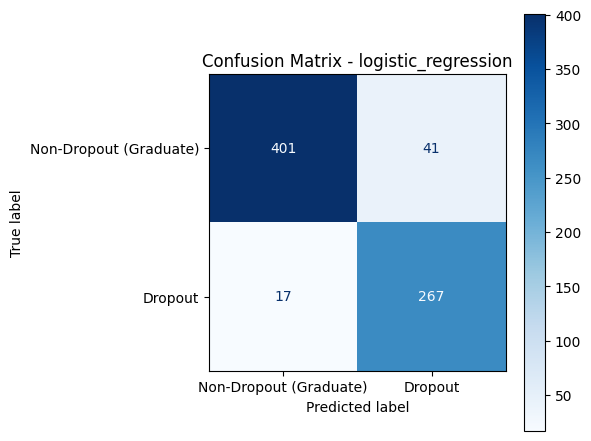

In [9]:
best_model_name = results_df.iloc[0]['model']
best_pipeline = fitted_pipelines[best_model_name]
best_probabilities = best_pipeline.predict_proba(X_test)[:, 1]
best_predictions = (best_probabilities >= 0.5).astype(int)

print(f"=== Model Terbaik Terpilih: {best_model_name} ===")
print(classification_report(y_test, best_predictions, target_names=['Non-Dropout', 'Dropout']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    display_labels=['Non-Dropout (Graduate)', 'Dropout'],
    cmap='Blues',
    ax=ax,
)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

### Analisis Error: False Negative vs False Positive
- **False Negative (FN)**: Mahasiswa yang sebenarnya berisiko dropout tetapi diprediksi aman/non-dropout. Kasus ini merupakan risiko terbesar bagi institusi karena mahasiswa yang membutuhkan bantuan tidak terdeteksi hingga akhirnya benar-benar keluar dari kampus.
- **False Positive (FP)**: Mahasiswa yang sebenarnya akan lulus tetapi diprediksi berisiko dropout. Mahasiswa ini mungkin akan menerima tawaran konseling atau verifikasi keuangan tambahan. Meskipun menimbulkan beban operasional kecil, konsekuensinya jauh lebih ringan dibandingkan kehilangan mahasiswa.
Oleh karena itu, prioritas utama metrik model adalah **Recall kelas Dropout** yang tinggi dengan tetap menjaga F1-score dan ROC-AUC yang seimbang.

## Ekspor Artefak Model

Menyimpan pipeline terbaik beserta metadata inference, termasuk daftar kategori valid untuk setiap input kategorikal, ke dalam file bundle `model/dropout_pipeline.joblib`.

In [10]:
category_values = {
    column: sorted(X_train[column].dropna().astype(int).unique().tolist())
    for column in categorical_columns
}

feature_defaults = {}
for column in X_train.columns:
    if column in categorical_columns:
        feature_defaults[column] = int(X_train[column].mode().iloc[0])
    else:
        feature_defaults[column] = float(X_train[column].median())

model_bundle = {
    'pipeline': best_pipeline,
    'feature_columns': X_train.columns.tolist(),
    'feature_defaults': feature_defaults,
    'categorical_columns': categorical_columns,
    'category_values': category_values,
    'model_name': best_model_name,
    'decision_threshold': 0.5,
    'positive_class': 'Dropout',
}

MODEL_PATH.parent.mkdir(exist_ok=True)
joblib.dump(model_bundle, MODEL_PATH)
print(f"Bundle model berhasil disimpan ke {MODEL_PATH}")

Bundle model berhasil disimpan ke model\dropout_pipeline.joblib


### Verifikasi Artefak Model Bundle

In [11]:
loaded_bundle = joblib.load(MODEL_PATH)
sample_frame = pd.DataFrame([loaded_bundle['feature_defaults']])[loaded_bundle['feature_columns']]
sample_probability = loaded_bundle['pipeline'].predict_proba(sample_frame)[:, 1]

assert set(loaded_bundle) == {
    'pipeline', 'feature_columns', 'feature_defaults', 'categorical_columns',
    'category_values',
    'model_name', 'decision_threshold', 'positive_class'
}
assert sample_frame.shape == (1, 36)
assert all(loaded_bundle['category_values'][column] for column in loaded_bundle['categorical_columns'])
assert 0.0 <= float(sample_probability[0]) <= 1.0
print(f"Verifikasi Berhasil! Model: {loaded_bundle['model_name']}")
print(f"Contoh probabilitas dropout untuk nilai default: {sample_probability[0]:.2%}")

Verifikasi Berhasil! Model: logistic_regression
Contoh probabilitas dropout untuk nilai default: 26.05%


## Conclusion

Dataset berisi 4.424 mahasiswa: 32,12% berstatus Dropout, 17,95% Enrolled, dan 49,93% Graduate. Analisis menunjukkan nilai mata kuliah semester 2 yang rendah, status pembayaran uang kuliah yang belum mutakhir, dan status Debtor berkaitan dengan risiko dropout yang lebih tinggi.

Model Logistic Regression terpilih berdasarkan recall kelas Dropout, dengan recall 94,01%, precision 86,69%, F1-score 90,20%, dan ROC-AUC 97,57% pada test set. Model ini dipakai sebagai sinyal awal untuk memprioritaskan intervensi akademik dan finansial; hasilnya bukan keputusan akademik otomatis.